In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
words = open('names.txt','r').read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [10]:
len(words)

32033

In [11]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [63]:
#building the dataset
block_size = 3
X,Y = [],[]
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '>>', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [184]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [13]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [14]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [64]:
X.shape

torch.Size([228146, 3])

In [16]:
C = torch.randn((27,2))
C

tensor([[-0.5976, -0.6405],
        [ 0.3609,  0.5887],
        [ 0.3019, -0.0203],
        [-3.0349, -0.5378],
        [-0.3338, -0.2555],
        [ 0.5339, -0.7608],
        [-0.5842,  1.5257],
        [ 0.9750,  1.1171],
        [-0.1651, -0.9634],
        [ 1.7758,  0.2286],
        [-0.4175, -1.1536],
        [ 0.6735, -0.3339],
        [-1.2645, -0.9487],
        [-0.0960, -0.5681],
        [-1.3917,  0.0905],
        [-1.3325,  0.6073],
        [ 0.1651,  0.0886],
        [-0.1016,  1.4542],
        [-1.0900,  0.3362],
        [-1.1977,  1.2402],
        [ 1.0706, -0.4026],
        [-0.4974, -1.1485],
        [-1.3881,  0.6637],
        [ 0.7053, -1.6126],
        [ 0.8272,  0.2179],
        [ 0.9856, -0.4210],
        [-0.2915, -0.6297]])

In [17]:
C[X]

tensor([[[-0.5976, -0.6405],
         [-0.5976, -0.6405],
         [-0.5976, -0.6405]],

        [[-0.5976, -0.6405],
         [-0.5976, -0.6405],
         [ 0.5339, -0.7608]],

        [[-0.5976, -0.6405],
         [ 0.5339, -0.7608],
         [-0.0960, -0.5681]],

        [[ 0.5339, -0.7608],
         [-0.0960, -0.5681],
         [-0.0960, -0.5681]],

        [[-0.0960, -0.5681],
         [-0.0960, -0.5681],
         [ 0.3609,  0.5887]],

        [[-0.5976, -0.6405],
         [-0.5976, -0.6405],
         [-0.5976, -0.6405]],

        [[-0.5976, -0.6405],
         [-0.5976, -0.6405],
         [-1.3325,  0.6073]],

        [[-0.5976, -0.6405],
         [-1.3325,  0.6073],
         [-1.2645, -0.9487]],

        [[-1.3325,  0.6073],
         [-1.2645, -0.9487],
         [ 1.7758,  0.2286]],

        [[-1.2645, -0.9487],
         [ 1.7758,  0.2286],
         [-1.3881,  0.6637]],

        [[ 1.7758,  0.2286],
         [-1.3881,  0.6637],
         [ 1.7758,  0.2286]],

        [[-1.3881,  0

In [18]:
C[X].shape

torch.Size([32, 3, 2])

In [19]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [20]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [21]:
torch.cat([emb[:, 0, :], emb[:, 0, :], emb[:, 0, :]], 1)

tensor([[-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [ 0.5339, -0.7608,  0.5339, -0.7608,  0.5339, -0.7608],
        [-0.0960, -0.5681, -0.0960, -0.5681, -0.0960, -0.5681],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-1.3325,  0.6073, -1.3325,  0.6073, -1.3325,  0.6073],
        [-1.2645, -0.9487, -1.2645, -0.9487, -1.2645, -0.9487],
        [ 1.7758,  0.2286,  1.7758,  0.2286,  1.7758,  0.2286],
        [-1.3881,  0.6637, -1.3881,  0.6637, -1.3881,  0.6637],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [ 0.3609,  0.5887,  0.3609,  0.5

In [22]:
torch.cat([emb[:, 0, :], emb[:, 0, :], emb[:, 0, :]], 0)

tensor([[-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [ 0.5339, -0.7608],
        [-0.0960, -0.5681],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-1.3325,  0.6073],
        [-1.2645, -0.9487],
        [ 1.7758,  0.2286],
        [-1.3881,  0.6637],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [ 0.3609,  0.5887],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [ 1.7758,  0.2286],
        [-1.1977,  1.2402],
        [ 0.3609,  0.5887],
        [ 0.3019, -0.0203],
        [ 0.5339, -0.7608],
        [-1.2645, -0.9487],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-1.1977,  1.2402],
        [-1.3325,  0.6073],
        [ 0.1651,  0.0886],
        [-0.1651, -0.9634],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [-0.5976, -0.6405],
        [ 0.5339, -0

In [23]:
torch.cat(torch.unbind(emb, 1), 1).shape #same as the that is already done 

torch.Size([32, 6])

In [24]:
emb.view(32, 6)

tensor([[-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405,  0.5339, -0.7608],
        [-0.5976, -0.6405,  0.5339, -0.7608, -0.0960, -0.5681],
        [ 0.5339, -0.7608, -0.0960, -0.5681, -0.0960, -0.5681],
        [-0.0960, -0.5681, -0.0960, -0.5681,  0.3609,  0.5887],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405, -1.3325,  0.6073],
        [-0.5976, -0.6405, -1.3325,  0.6073, -1.2645, -0.9487],
        [-1.3325,  0.6073, -1.2645, -0.9487,  1.7758,  0.2286],
        [-1.2645, -0.9487,  1.7758,  0.2286, -1.3881,  0.6637],
        [ 1.7758,  0.2286, -1.3881,  0.6637,  1.7758,  0.2286],
        [-1.3881,  0.6637,  1.7758,  0.2286,  0.3609,  0.5887],
        [-0.5976, -0.6405, -0.5976, -0.6405, -0.5976, -0.6405],
        [-0.5976, -0.6405, -0.5976, -0.6405,  0.3609,  0.5887],
        [-0.5976, -0.6405,  0.3609,  0.5887, -1.3881,  0.6637],
        [ 0.3609,  0.5887, -1.3881,  0.6

In [25]:
(emb.view(32, 6) @ W1).shape

torch.Size([32, 100])

In [26]:
W1.shape

torch.Size([6, 100])

In [30]:
h = torch.tanh(emb.view(32, 6) @ W1 + b1) # (32, 6) @ (6, 100) = (32, 100)

In [31]:
h

tensor([[-0.9957, -0.0018, -0.9992,  ..., -0.6530, -0.7180, -0.9862],
        [-0.8839,  0.7530, -0.9985,  ..., -0.4082,  0.8516, -0.9773],
        [-0.5434,  0.9214, -0.9994,  ..., -0.9683,  0.9861, -0.5310],
        ...,
        [-0.8503,  0.2241, -0.9945,  ..., -0.8237,  0.9984, -0.8643],
        [ 0.8080,  0.9377, -0.9413,  ...,  0.8942,  0.9994, -0.6986],
        [ 0.9933,  0.9998, -0.9298,  ..., -0.9995,  0.9992,  0.9804]])

In [32]:
h.shape

torch.Size([32, 100])

In [33]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [36]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [35]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(14.6737)

In [185]:
#asli cheez

In [216]:
print(Xtr.shape)
print(Ytr.shape)

torch.Size([182625, 3])
torch.Size([182625])


In [252]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [253]:
sum(p.nelement() for p in parameters)

11897

In [254]:
for p in parameters:
    p.requires_grad = True

In [255]:
lrs = lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [256]:
#graph purpose
#lri = []
lossi = []
stepi = []

In [277]:
for i in range(50000):
    # making mini batches 
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    #counts = logits.exp()
    #probs = counts / counts.sum(1, keepdims = True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #updation
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad
    #print(loss.item())
    #tracking status
    #lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)

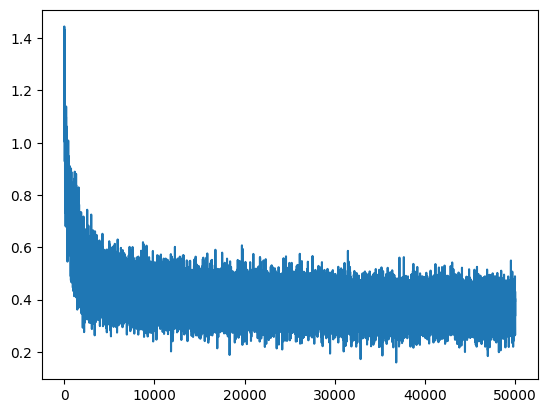

In [258]:
# 3rd plot
plt.plot(stepi, lossi)

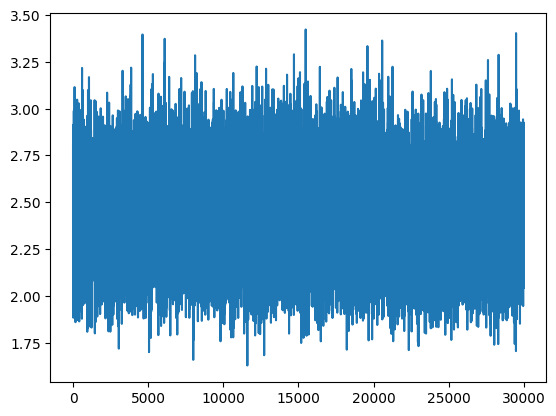

In [240]:
#second one
plt.plot(stepi, lossi)

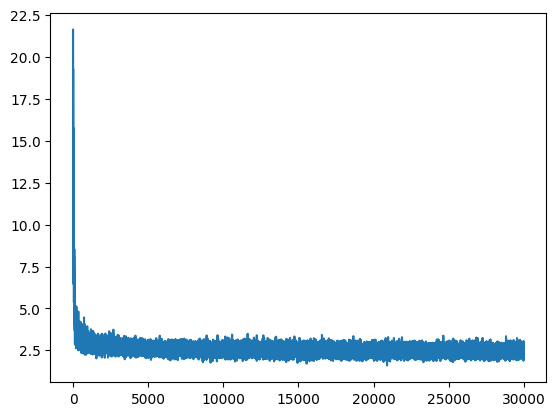

In [238]:
#first one
plt.plot(stepi, lossi)

In [246]:
print(loss.item())

2.311890125274658


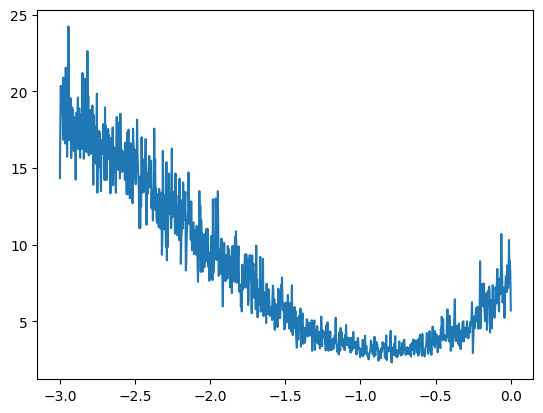

In [164]:
plt.plot(lri, lossi)

In [278]:
#total loss (training loss)
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.1910483837127686

In [279]:
#total loss (dev loss)
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.2267720699310303

In [43]:
Y.shape

torch.Size([32])

In [61]:
logits.max(1)

torch.return_types.max(
values=tensor([12.5744, 16.0736, 19.8097, 18.9364, 16.3615, 12.5744, 15.0645, 13.1258,
        14.9385, 17.2840, 14.6740, 19.7479, 12.5744, 16.0587, 16.4647, 17.8092,
        12.5744, 15.5095, 14.2626, 15.8888, 18.1420, 14.9797,  9.8492,  9.9332,
        14.7283, 12.5744, 15.4265, 15.8772, 12.3309, 15.3393, 18.2754, 15.2761],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1, 13, 13,  1,  0,  1, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  1, 19,
         1,  2,  5, 12, 12,  1,  0,  1, 15, 16,  8,  9,  1,  0]))

In [62]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [250]:
#process to find the good learning rate
#training 90% dev/validation split 10%test spli 10%

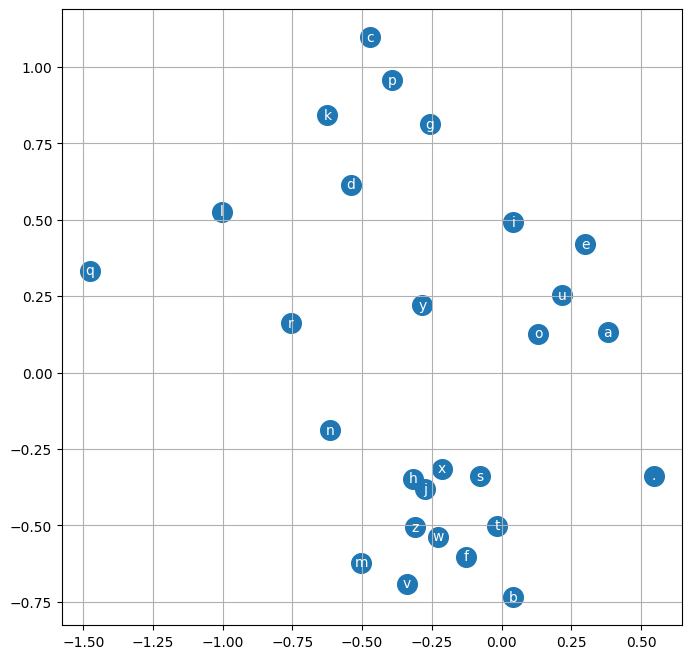

In [251]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [275]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [276]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carma.
fatu.
harif.
jarri.
taty.
sachyskeja.
hube.
ameryna.
kaeli.
ner.
kia.
chaiivon.
leigh.
ham.
jorn.
quint.
srogsen.
jadis.
wazelo.
dearynix.
